<a href="https://colab.research.google.com/github/Sikandarh11/Feature-Engineering/blob/main/Task_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### `Task` How dimensionality reduction using Principal Component Analysis (PCA) on the Wine Quality dataset contributes to improving the classification accuracy and efficiency of wine type.

Note : Use KNN for Classification.

Data Link :  [Wine Data](https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv)

In [203]:
# Data Loading
import pandas as pd
wine_data_path = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv"
wine = pd.read_csv(wine_data_path)
wine.head(1)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6


In [204]:
wine['quality'].unique()

array([6, 5, 7, 8, 4, 3, 9])

In [205]:
wine.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [206]:
wine = wine.dropna(axis = 0)

In [211]:
wine.isnull().sum()

type                    32
fixed acidity           32
volatile acidity        32
citric acid             32
residual sugar          32
chlorides               32
free sulfur dioxide     32
total sulfur dioxide    32
density                 32
pH                      32
sulphates               32
alcohol                 32
quality                 32
Type                    32
dtype: int64

In [212]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output = False, drop= 'first')
typ = ohe.fit_transform(wine[['type']]).astype(int)
typ.shape

(6495, 2)

In [213]:
typ.shape, wine['type'].shape

((6495, 2), (6495,))

In [214]:
typ = pd.DataFrame(typ[:, :1], columns = ['Type'])
wine = pd.concat([wine, typ], axis=1, join= 'outer')

In [215]:
wine.isnull().sum()

type                    34
fixed acidity           34
volatile acidity        34
citric acid             34
residual sugar          34
chlorides               34
free sulfur dioxide     34
total sulfur dioxide    34
density                 34
pH                      34
sulphates               34
alcohol                 34
quality                 34
Type                    34
Type                     2
dtype: int64

In [216]:
wine = wine.dropna(axis=0)

In [217]:
y = wine['quality']

In [218]:
wine = wine.drop(['type'], axis = 1)

In [219]:
wine.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Type,Type
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6.0,1.0,1.0
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.994,3.3,0.49,9.5,6.0,1.0,1.0


In [220]:
X = wine.drop(['quality'], axis=1)

In [221]:
X.head(1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Type,Type
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,1.0,1.0


In [222]:
y.isnull().sum()

0

In [223]:
X.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Type                    0
Type                    0
dtype: int64

In [224]:
# Your Code goes Here
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

In [225]:
X.shape, y.shape

((6431, 13), (6431,))

In [226]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
x_train, x_test, y_train, y_test = train_test_split(X, y)

In [227]:
x_test.shape

(1608, 13)

In [228]:
y_train.isnull().sum()

0

In [229]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [230]:
pred = knn.predict(x_test)

In [231]:
from sklearn.metrics import accuracy_score
accuracy_score(pred, y_test)

0.4832089552238806

In [232]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 12)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.fit_transform(x_test)

In [233]:
x_train_trf.shape

(4823, 12)

In [234]:
knnPCA = KNeighborsClassifier()
knnPCA.fit(x_train_trf, y_train)
predPCA = knnPCA.predict(x_test_trf)
accuracy_score(predPCA, y_test)

0.4689054726368159

In [235]:
check = []
for i in range(1,13):
  pcaCheck = PCA(n_components = i)
  print(i)
  x_train_Check = pcaCheck.fit_transform(x_train)
  x_test_Check = pcaCheck.fit_transform(x_test)

  Knn = KNeighborsClassifier()
  Knn.fit(x_train_Check, y_train)

  check.append(accuracy_score(y_test, Knn.predict(x_test_Check)))

1
2
3
4
5
6
7
8
9
10
11
12


In [236]:
check

[0.3675373134328358,
 0.4154228855721393,
 0.42661691542288555,
 0.4521144278606965,
 0.46828358208955223,
 0.4701492537313433,
 0.47139303482587064,
 0.47077114427860695,
 0.4695273631840796,
 0.4689054726368159,
 0.4689054726368159,
 0.4689054726368159]

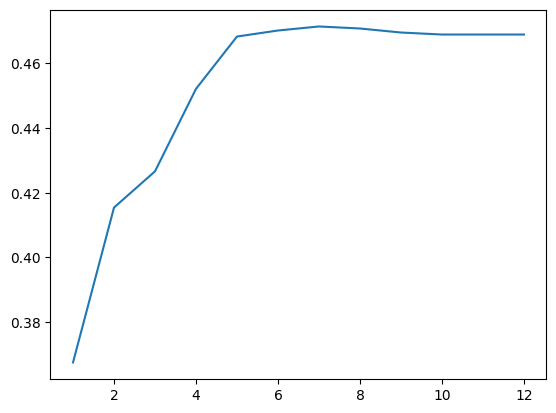

In [237]:
import matplotlib.pyplot as plt
plt.plot(range(1,13), check)

In [239]:
pcaFinal = PCA(n_components = 5)
x_train_F = pcaFinal.fit_transform(x_train)
x_test_F = pcaFinal.fit_transform(x_test)

knnF = KNeighborsClassifier()
knnF.fit(x_train_trf, y_train)
predF = knnF.predict(x_test_trf)
accuracy_score(predF, y_test)

0.4689054726368159